# 3단계: 시/도별 개선율 및 SAW 결과 시각화

이 노트북은 `step2_sido_improvement_saw.ipynb`에서 생성한 CSV 파일을 읽어 시각화한다.

**확인할 그래프**
1. PM2.5 개선율 막대그래프 (전남·경북 PM2.5 분석 제외)
2. PM10 개선율 막대그래프 (17개 시/도)
3. 편향 점검 그래프
   - 시/도별 PM10 vs PM2.5 측정소 수 비교 막대그래프
   - 시/도별 PM2.5 분석 시작 연도 막대그래프 (전남·경북 제외 표시)
4. PM2.5 개선율 vs 시행 후 PM2.5 절대농도 산점도 (전남·경북 PM2.5 분석 제외)
5. SAW 점수 막대그래프 (PM2.5 기준 15개 시/도만 유효)
6. 2017~2019 vs 2020~ 구간 변화율 비교 그래프 (PM10 / PM2.5)

그래프 해석의 핵심은 **개선율이 낮고, 시행 후 PM2.5 절대농도가 높은 지역**을 찾는 것이다.

## 0. 라이브러리 및 경로 설정

실행 위치가 프로젝트 루트일 수도 있고 `src` 폴더일 수도 있으므로, 두 경로를 모두 후보로 둔다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# 한글 그래프 깨짐 방지. Windows 환경에서는 Malgun Gothic이 보통 사용 가능하다.
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 그래프 기본 스타일. 너무 화려하지 않게 보고서용으로 설정한다.
sns.set_theme(style="whitegrid", font="Malgun Gothic")


DATA_DIR_CANDIDATES = [
    Path("data/processed"),
    Path("../data/processed"),
]


def resolve_existing_dir(candidates: list[Path]) -> Path:
    """후보 폴더 중 실제 존재하는 첫 번째 경로를 반환한다."""
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"폴더를 찾을 수 없습니다: {candidates}")


DATA_DIR = resolve_existing_dir(DATA_DIR_CANDIDATES)

IMPROVEMENT_PATH  = DATA_DIR / "sido_winter_improvement.csv"
BIAS_PATH         = DATA_DIR / "sido_winter_bias_check.csv"
SAW_PATH          = DATA_DIR / "sido_saw_input_equal_weight.csv"
COMPARE_PATH      = DATA_DIR / "sido_period_compare_2017_2020.csv"

print("데이터 폴더:", DATA_DIR)
print("개선율 파일:", IMPROVEMENT_PATH)
print("편향 점검 파일:", BIAS_PATH)
print("SAW 파일:", SAW_PATH)
print("구간 비교 파일:", COMPARE_PATH)

데이터 폴더: ..\data\processed
개선율 파일: ..\data\processed\sido_winter_improvement.csv
편향 점검 파일: ..\data\processed\sido_winter_bias_check.csv
SAW 파일: ..\data\processed\sido_saw_input_equal_weight.csv
구간 비교 파일: ..\data\processed\sido_period_compare_2017_2020.csv


## 1. Step2 결과 CSV 읽기

네 파일을 읽는다.

- `sido_winter_improvement.csv`: 시행 전후 평균 및 개선율 (PM10 17개 + PM2.5 15개 outer merge)
- `sido_winter_bias_check.csv`: 측정소 수, 관측 일수, PM2.5 시작 연도 점검표
- `sido_saw_input_equal_weight.csv`: SAW 기준값, 정규화 점수, 동일가중 순위
- `sido_period_compare_2017_2020.csv`: 2017~2019 vs 2020~ 구간 변화율 비교 (신규)

In [2]:
improvement = pd.read_csv(IMPROVEMENT_PATH)
bias = pd.read_csv(BIAS_PATH)
saw = pd.read_csv(SAW_PATH)
period_compare = pd.read_csv(COMPARE_PATH)

print("개선율:", improvement.shape, "  컬럼:", list(improvement.columns))
print("편향 점검:", bias.shape, "  컬럼:", list(bias.columns))
print("SAW:", saw.shape)
print("구간 비교:", period_compare.shape)

improvement.head()

개선율: (17, 7)   컬럼: ['sido', 'pm10_before', 'pm10_after', 'pm10_improvement_rate', 'pm25_before', 'pm25_after', 'pm25_improvement_rate']
편향 점검: (17, 7)   컬럼: ['sido', 'pm10_station_count', 'pm10_obs_days', 'pm25_station_count', 'pm25_obs_days', 'pm25_start_year', 'pm25_excluded']
SAW: (17, 9)
구간 비교: (17, 7)


,sido,pm10_before,pm10_after,pm10_improvement_rate,pm25_before,pm25_after,pm25_improvement_rate
0,세종,52.310728,46.276427,11.535496,29.815828,26.073310,12.552117
1,인천,52.565747,44.061764,16.177803,30.538654,25.187223,17.523469
2,서울,53.532668,44.028373,17.754197,31.948771,25.613491,19.829495
3,대구,48.707147,40.175097,17.517039,29.029343,22.929954,21.011116
4,충남,51.508348,47.354286,8.064832,35.163300,27.619992,21.452218


## 2. PM2.5 개선율 막대그래프

PM2.5 개선율이 낮은 지역일수록 개선이 미흡한 지역이다. 따라서 낮은 순서로 정렬해 확인한다.
전남·경북은 PM2.5 측정망이 분석 기준(2018년 이전 유효 관측)에 미달하여 PM2.5 분석에서 제외된다.

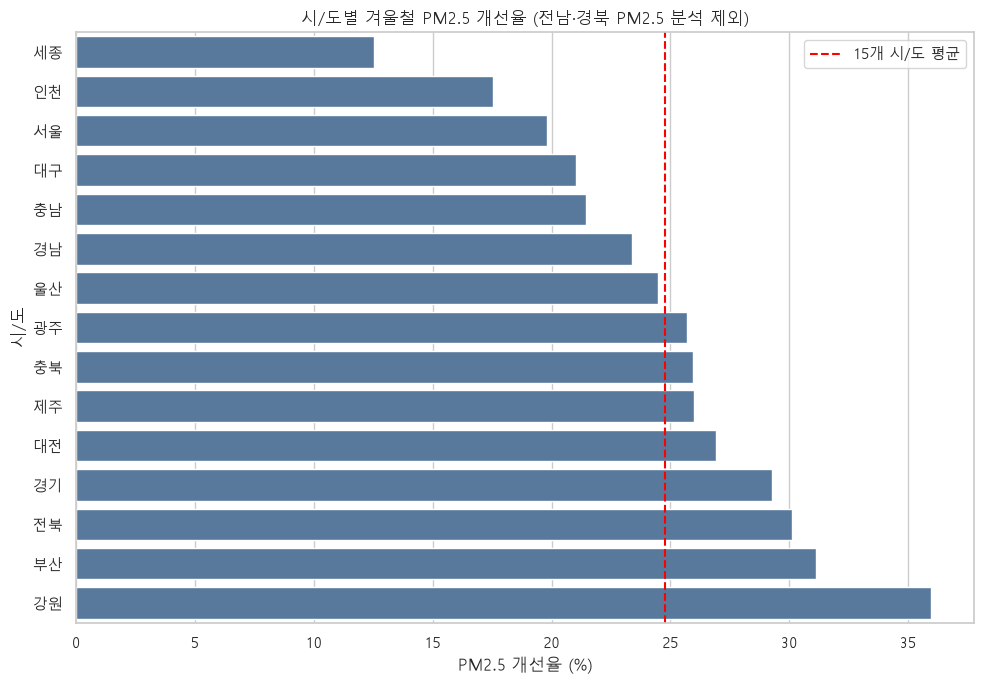

In [3]:
# 전남·경북은 pm25_improvement_rate가 NaN이므로 명시적으로 제외한다.
plot_df = improvement.dropna(subset=["pm25_improvement_rate"]).sort_values(
    "pm25_improvement_rate", ascending=True
)

# 실제 유효 시/도 수를 동적으로 계산해 평균선 라벨에 반영한다.
n_valid = plot_df["pm25_improvement_rate"].notna().sum()

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=plot_df,
    x="pm25_improvement_rate",
    y="sido",
    ax=ax,
    color="#4C78A8",
)
ax.axvline(
    plot_df["pm25_improvement_rate"].mean(),
    color="red",
    linestyle="--",
    label=f"{n_valid}개 시/도 평균",
)
ax.set_title("시/도별 겨울철 PM2.5 개선율 (전남·경북 PM2.5 분석 제외)")
ax.set_xlabel("PM2.5 개선율 (%)")
ax.set_ylabel("시/도")
ax.legend()
plt.tight_layout()
plt.show()

## 3. PM10 개선율 막대그래프

PM10 개선율도 같은 방식으로 확인한다. PM2.5와 PM10의 개선 양상이 같은지 비교하는 데 쓴다.
PM10은 전남·경북 포함 17개 시/도 전부 유효하다.

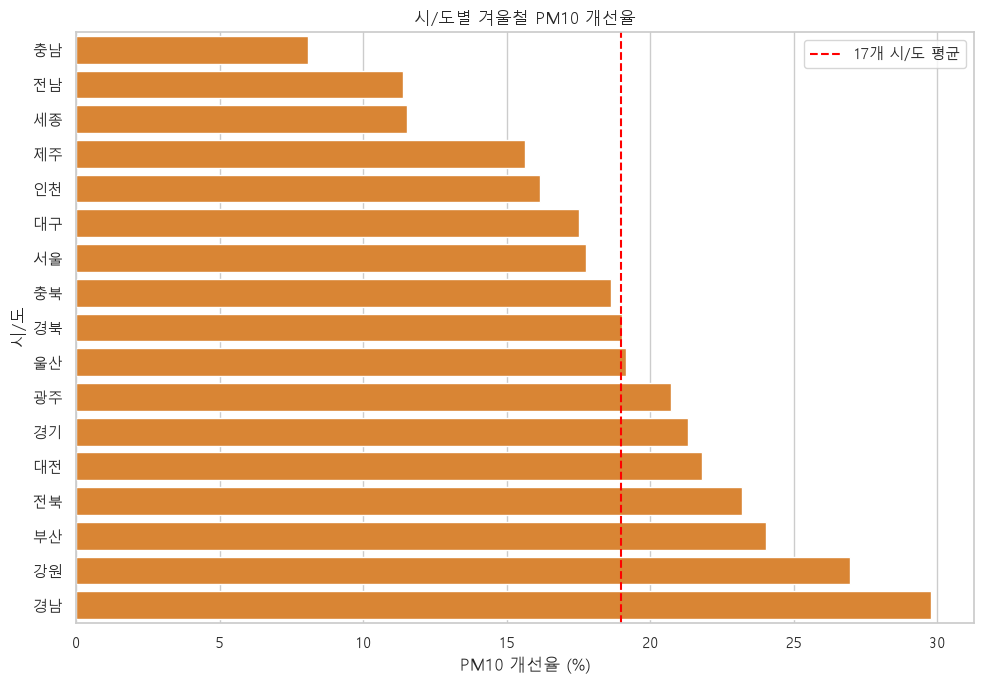

In [4]:
plot_df = improvement.sort_values("pm10_improvement_rate", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=plot_df,
    x="pm10_improvement_rate",
    y="sido",
    ax=ax,
    color="#F58518",
)
ax.axvline(plot_df["pm10_improvement_rate"].mean(), color="red", linestyle="--", label="17개 시/도 평균")
ax.set_title("시/도별 겨울철 PM10 개선율")
ax.set_xlabel("PM10 개선율 (%)")
ax.set_ylabel("시/도")
ax.legend()
plt.tight_layout()
plt.show()

## 4. 편향 점검 1: PM10 vs PM2.5 측정소 수 비교

`processed_by_region` 데이터는 이미 결측치 제거가 완료된 상태라 결측률 재계산은 의미가 없다.
대신 PM10 측정소 수와 PM2.5 측정소 수를 시/도별로 나란히 비교해, 두 오염물질 간 관측 규모 차이를 확인한다.

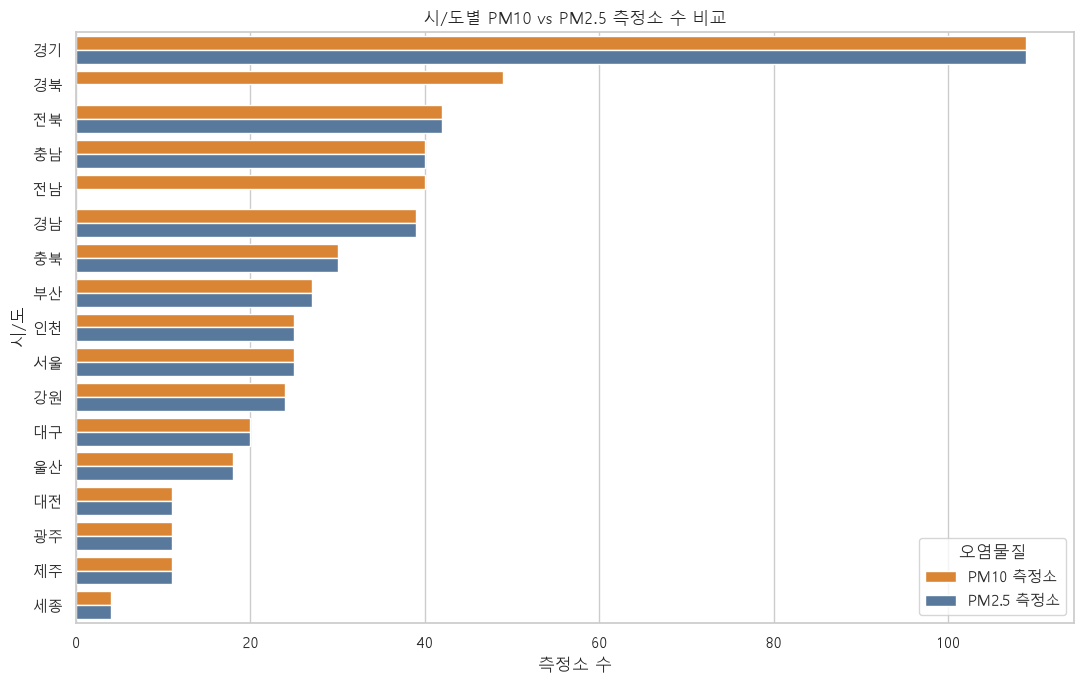

In [5]:
# PM10 측정소 수 기준 내림차순으로 시/도 순서를 정한다.
station_order = (
    bias.sort_values("pm10_station_count", ascending=False)["sido"]
    .tolist()
)

# wide → long 변환: 측정소 수 두 컬럼을 하나의 hue로 표현한다.
station_long = bias[["sido", "pm10_station_count", "pm25_station_count"]].melt(
    id_vars="sido",
    value_vars=["pm10_station_count", "pm25_station_count"],
    var_name="오염물질",
    value_name="측정소 수",
)
station_long["오염물질"] = station_long["오염물질"].map(
    {"pm10_station_count": "PM10 측정소", "pm25_station_count": "PM2.5 측정소"}
)

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(
    data=station_long,
    x="측정소 수",
    y="sido",
    hue="오염물질",
    order=station_order,
    ax=ax,
    palette=["#F58518", "#4C78A8"],
)
ax.set_title("시/도별 PM10 vs PM2.5 측정소 수 비교")
ax.set_xlabel("측정소 수")
ax.set_ylabel("시/도")
ax.legend(title="오염물질")
plt.tight_layout()
plt.show()

## 5. 편향 점검 2: PM2.5 분석 시작 연도

PM2.5 측정망 확충 시점이 지역마다 다르기 때문에 `before(2015~2018)` 구간의 데이터 길이도 지역별로 다르다.
시작 연도가 늦을수록 before 구간 표본이 적어 개선율 해석에 주의해야 한다.
전남·경북은 분석 기준 미달로 PM2.5 분석에서 제외되므로 다른 색으로 표시한다.

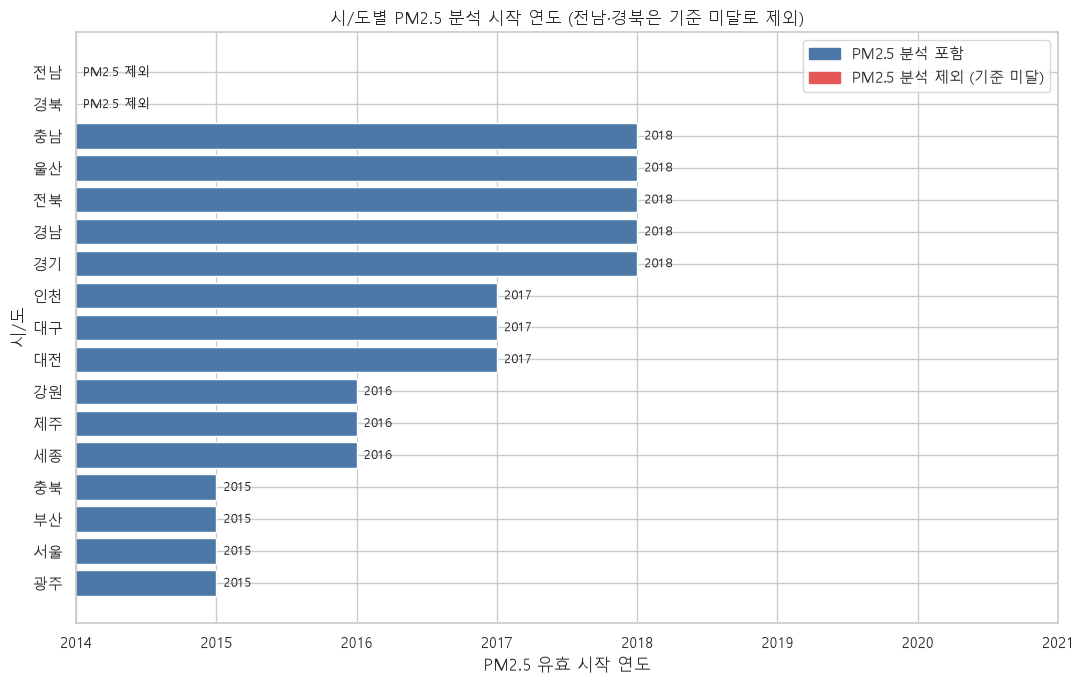

In [6]:
# PM2.5 시작 연도 기준 오름차순으로 정렬한다 (시작이 빠를수록 before 구간이 길다).
# pm25_excluded == True인 전남·경북은 pm25_start_year가 NaN이므로 따로 처리한다.
bias_pm25 = bias.copy()
bias_pm25["pm25_start_year_label"] = bias_pm25["pm25_start_year"].apply(
    lambda y: str(int(y)) if pd.notna(y) else "제외"
)

# 시작 연도 오름차순 + 제외 시/도를 마지막으로 보내는 정렬 순서를 만든다.
start_year_order = (
    bias_pm25[bias_pm25["pm25_excluded"] == False]
    .sort_values("pm25_start_year")["sido"]
    .tolist()
    + bias_pm25[bias_pm25["pm25_excluded"] == True]["sido"].tolist()
)

# 분석 포함/제외에 따라 색을 구분한다.
color_map = bias_pm25.set_index("sido")["pm25_excluded"].map({False: "#4C78A8", True: "#E45756"})
bar_colors = [color_map[s] for s in start_year_order]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(
    y=start_year_order,
    width=[
        bias_pm25.set_index("sido").loc[s, "pm25_start_year"]
        if pd.notna(bias_pm25.set_index("sido").loc[s, "pm25_start_year"])
        else 0
        for s in start_year_order
    ],
    color=bar_colors,
)

# 막대 위에 연도(또는 '제외') 텍스트를 표시한다.
for sido in start_year_order:
    row = bias_pm25.set_index("sido").loc[sido]
    label = str(int(row["pm25_start_year"])) if pd.notna(row["pm25_start_year"]) else "PM2.5 제외"
    x_val = row["pm25_start_year"] if pd.notna(row["pm25_start_year"]) else 2014
    ax.text(x_val + 0.05, sido, label, va="center", fontsize=9)

# 범례를 직접 추가한다 (bar 색상이 hue가 아닌 수동 지정이므로).
from matplotlib.patches import Patch
legend_handles = [
    Patch(color="#4C78A8", label="PM2.5 분석 포함"),
    Patch(color="#E45756", label="PM2.5 분석 제외 (기준 미달)"),
]
ax.legend(handles=legend_handles)
ax.set_title("시/도별 PM2.5 분석 시작 연도 (전남·경북은 기준 미달로 제외)")
ax.set_xlabel("PM2.5 유효 시작 연도")
ax.set_ylabel("시/도")
ax.set_xlim(2014, 2021)
plt.tight_layout()
plt.show()

## 6. PM2.5 개선율 vs 시행 후 PM2.5 절대농도 산점도

의사결정 관점에서 가장 중요한 그래프다.

- 왼쪽: 개선율이 낮음
- 위쪽: 시행 후 PM2.5 절대농도가 높음

따라서 **왼쪽 위**에 있는 지역은 개선이 미흡하면서 현재 오염 부담도 큰 우선관리 후보로 볼 수 있다.
전남·경북은 PM2.5 분석에서 제외되므로 이 산점도에도 표시되지 않는다.

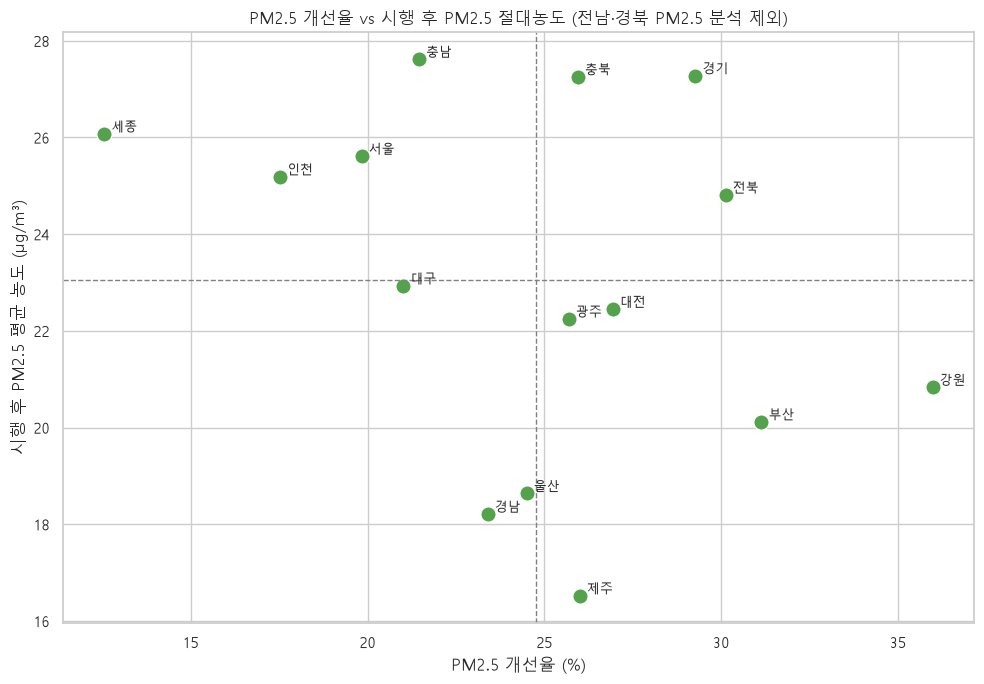

In [7]:
# 전남·경북은 pm25 관련 컬럼이 NaN이므로 명시적으로 제외한다.
scatter_df = improvement.dropna(subset=["pm25_improvement_rate", "pm25_after"])

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=scatter_df,
    x="pm25_improvement_rate",
    y="pm25_after",
    s=120,
    color="#54A24B",
    ax=ax,
)

# 평균선을 그어 사분면 해석을 쉽게 만든다.
x_mean = scatter_df["pm25_improvement_rate"].mean()
y_mean = scatter_df["pm25_after"].mean()
ax.axvline(x_mean, color="gray", linestyle="--", linewidth=1)
ax.axhline(y_mean, color="gray", linestyle="--", linewidth=1)

# 각 점에 시/도명을 표시한다.
for _, row in scatter_df.iterrows():
    ax.text(
        row["pm25_improvement_rate"] + 0.2,
        row["pm25_after"] + 0.05,
        row["sido"],
        fontsize=9,
    )

ax.set_title("PM2.5 개선율 vs 시행 후 PM2.5 절대농도 (전남·경북 PM2.5 분석 제외)")
ax.set_xlabel("PM2.5 개선율 (%)")
ax.set_ylabel("시행 후 PM2.5 평균 농도 (µg/m³)")
plt.tight_layout()
plt.show()

## 7. SAW 점수 막대그래프

동일가중 SAW 기준 우선순위 결과를 점수 순으로 확인한다. 점수가 높을수록 관리 자원 우선 배분 후보에 가깝다.
PM2.5 관련 컬럼이 NaN인 전남·경북은 SAW 점수도 NaN이므로 그래프에서 자동으로 제외된다 (PM2.5 기준 유효 시/도 15개).

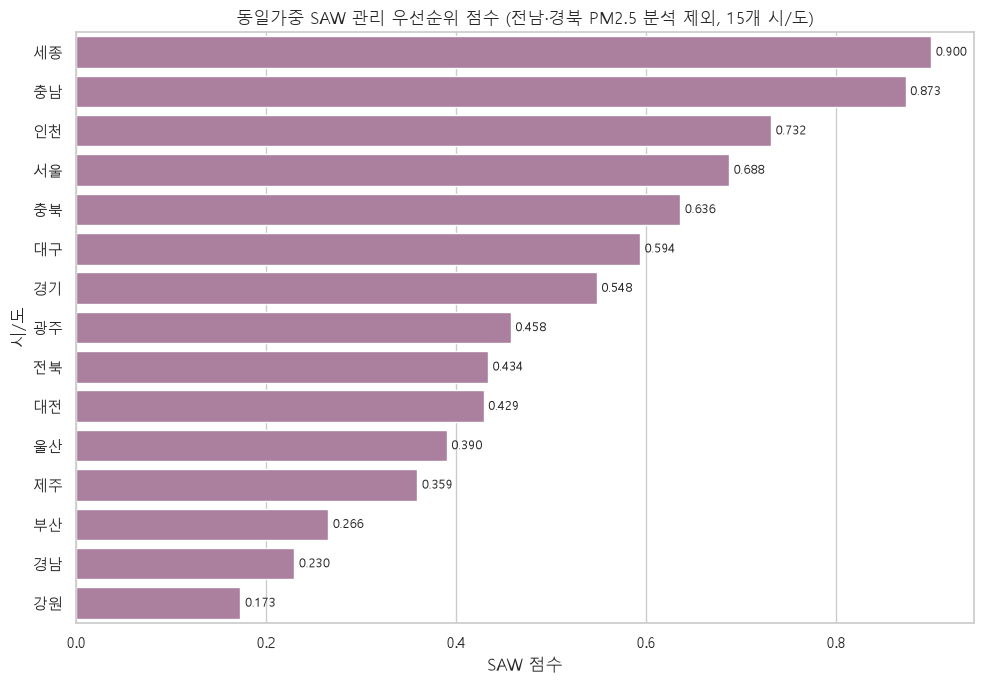

In [8]:
# saw_score_equal_weight가 NaN인 시/도(전남·경북)는 명시적으로 제외한다.
saw_valid = saw.dropna(subset=["saw_score_equal_weight"])
plot_df = saw_valid.sort_values("saw_score_equal_weight", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=plot_df,
    x="saw_score_equal_weight",
    y="sido",
    ax=ax,
    color="#B279A2",
)
ax.set_title("동일가중 SAW 관리 우선순위 점수 (전남·경북 PM2.5 분석 제외, 15개 시/도)")
ax.set_xlabel("SAW 점수")
ax.set_ylabel("시/도")

# 막대 오른쪽에 점수를 표시한다.
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## 8. 2017~2019 vs 2020~ 구간 변화율 비교

2017년 이전 데이터는 PM2.5 측정망이 일부 시/도에서 미비해 결측치가 커서 그대로 쓰면 해석이 왜곡될 수 있다.
따라서 `winter_year` 기준 **2017~2019 구간**(상대적으로 데이터가 안정된 시점)과
**2020년 이후 구간**의 시/도별 평균 농도를 비교하고, 그 변화율을 시각화한다.
전남·경북은 PM2.5 분석에서 제외되므로 PM2.5 변화율 그래프에는 표시되지 않는다.

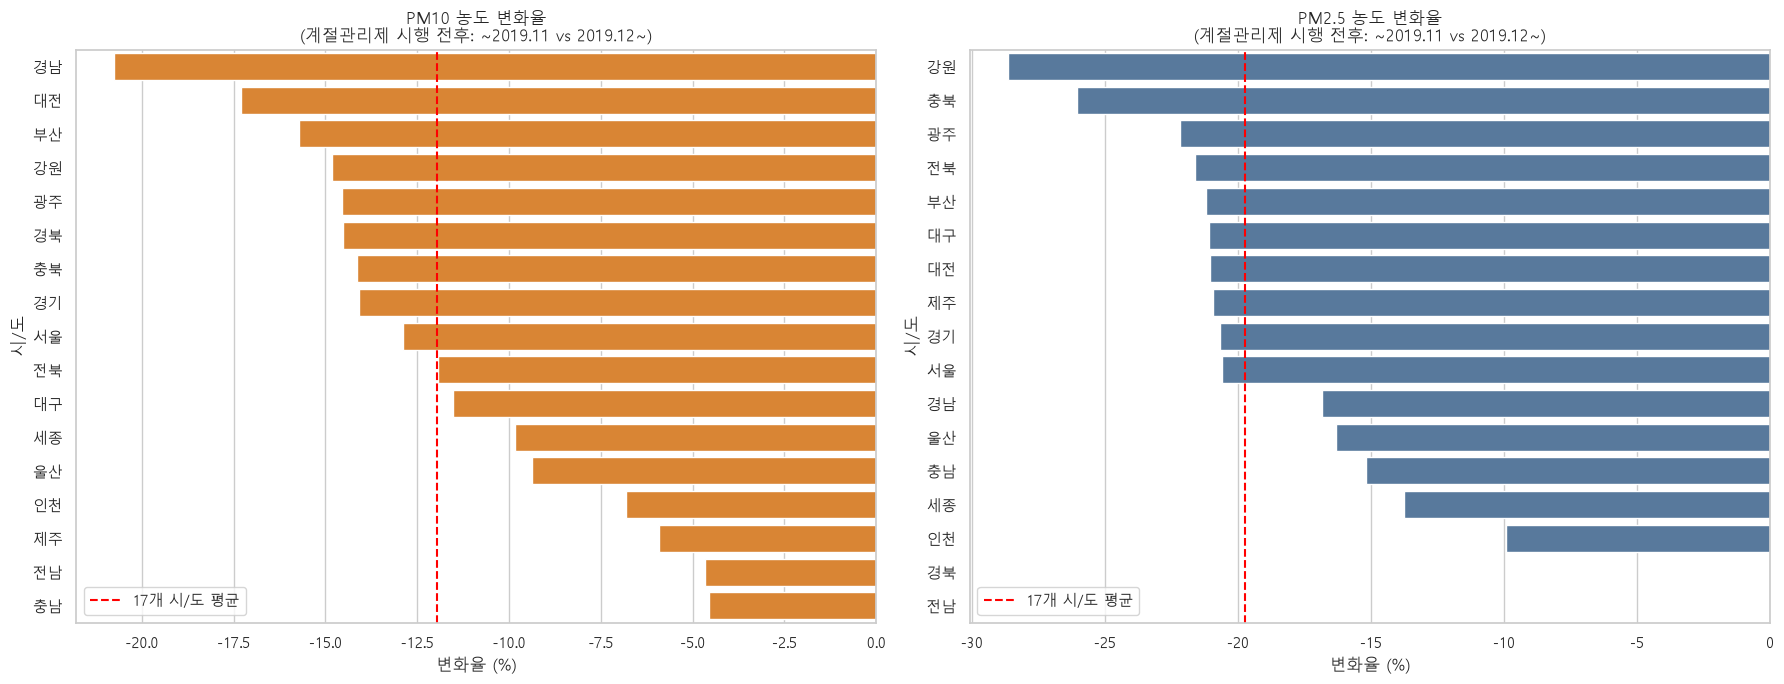

In [10]:
# ── PM10 및 PM2.5 변화율: 계절관리제 시행 전후 ──────────────────────────────
# 변화율이 큰(감소) 순서로 정렬한다. 음수 값이 클수록 개선이 많이 됐다는 뜻이다.
pm10_cmp_order = (
    period_compare.sort_values("pm10_change_rate", ascending=True)["sido"]
    .tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PM10 변화율 ---
ax = axes[0]
sns.barplot(
    data=period_compare,
    x="pm10_change_rate",
    y="sido",
    order=pm10_cmp_order,
    ax=ax,
    color="#F58518",
)
ax.axvline(period_compare["pm10_change_rate"].mean(), color="red", linestyle="--",
           label=f"{len(period_compare)}개 시/도 평균")
# 제목 수정: 계절관리제 시행 전후 기간 명시
ax.set_title("PM10 농도 변화율\n(계절관리제 시행 전후: ~2019.11 vs 2019.12~)")
ax.set_xlabel("변화율 (%)")
ax.set_ylabel("시/도")
ax.legend()

# --- PM2.5 변화율 ---
pm25_cmp_order = (
    period_compare.sort_values("pm25_change_rate", ascending=True)["sido"]
    .tolist()
)

ax = axes[1]
sns.barplot(
    data=period_compare,
    x="pm25_change_rate",
    y="sido",
    order=pm25_cmp_order,
    ax=ax,
    color="#4C78A8",
)
ax.axvline(period_compare["pm25_change_rate"].mean(), color="red", linestyle="--",
           label=f"{len(period_compare)}개 시/도 평균")

ax.set_title("PM2.5 농도 변화율\n(계절관리제 시행 전후: ~2019.11 vs 2019.12~)")
ax.set_xlabel("변화율 (%)")
ax.set_ylabel("시/도")
ax.legend()

plt.tight_layout()
plt.show()

## 9. 해석 메모

보고서에는 다음 흐름으로 해석하면 자연스럽다.

1. PM2.5/PM10 개선율 막대그래프로 시/도별 개선폭 차이를 확인한다.
2. 편향 점검 그래프(측정소 수, PM2.5 시작 연도)로 데이터 신뢰도를 점검한다.
3. 산점도로 개선율이 낮고 시행 후 PM2.5 농도가 높은 지역을 찾는다.
4. SAW 점수 막대그래프로 최종 우선순위 후보를 제시한다.
5. 2017~2019 vs 2020~ 비교 그래프로 최근 추세를 교차 검증한다.

### 편향 점검 그래프 변경 이유
- 기존 결측률 그래프(PM2.5/PM10 결측률 시행 전후 비교)는 `processed_by_region` 데이터가
  이미 결측치를 제거한 상태라 재계산해도 의미가 없어 삭제했다.
- 대신 시/도별 **측정소 수 비교**와 **PM2.5 유효 시작 연도**를 표시해,
  측정 규모와 before 구간 표본 길이 차이를 한눈에 파악할 수 있게 했다.

### 전남·경북 PM2.5 제외 처리
- 전남(유효 시작 2019-12), 경북(2020-04)은 2018년 이전 유효 관측 기준에 미달하여
  PM2.5 분석에서 제외된다. 이 두 지역은 PM2.5 관련 컬럼이 NaN으로 남는다.
- PM2.5 개선율 그래프, 산점도, SAW 그래프, PM2.5 구간 비교 그래프에서는
  `.dropna(subset=[...])` 으로 명시적으로 제외하고 제목에도 이를 표기했다.
- PM10은 두 지역 포함 17개 시/도 전부 유효하다.

### 2017~2019 vs 2020~ 비교 그래프 해석법
- 이 그래프는 계절관리제 전체 기간(2015~2018)을 before로 쓰는 대신, 결측이 적은
  2017~2019 구간만을 비교 기준으로 삼아 결측 편향을 줄인 보조 분석이다.
- 변화율이 음수이면 농도가 감소(개선)한 것이고, 양수이면 증가한 것이다.
- 이 결과와 전체 구간 개선율(셀 2~3)이 방향은 같지만 크기가 다를 수 있는데,
  그 차이가 2015~2016년 초기 결측 편향 때문인지를 검토해야 한다.

주의할 점은 이 분석이 전후 비교 기반이라는 것이다. 코로나19, 중국발 오염 변화,
산업 구조 변화, 측정망 변화 같은 외부 요인을 완전히 분리한 인과효과 분석은 아니다.